<a href="https://colab.research.google.com/github/RANGAM-AKHILA/RANGAM-AKHILA/blob/main/Dialect_Identification_WavLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q numpy pandas matplotlib scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q tqdm scikit-learn pandas matplotlib numpy

Train Samples      : 6000
Validation Samples : 1000

Found existing checkpoint.
Completed Layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


Processing Layers:   0%|          | 0/13 [00:00<?, ?layer/s]

Layer 0 already completed.
Layer 1 already completed.
Layer 2 already completed.
Layer 3 already completed.
Layer 4 already completed.
Layer 5 already completed.
Layer 6 already completed.
Layer 7 already completed.
Layer 8 already completed.
Layer 9 already completed.
Layer 10 already completed.
Layer 11 already completed.
Layer 12 already completed.


LAYER-WISE RESULTS
    Layer  Accuracy (%)
0       0          43.2
1       1          43.4
2       2          40.3
3       3          45.1
4       4          45.9
5       5          50.1
6       6          49.7
7       7          52.6
8       8          47.2
9       9          50.1
10     10          49.4
11     11          52.8
12     12          51.1


DIALECT-WISE RESULTS
 Layer  Overall        D1        D2        D3        D4
     0     43.2       NaN       NaN       NaN       NaN
     1     43.4 56.273764 42.222222 29.850746 42.105263
     2     40.3 47.908745 35.185185 36.318408 40.977444
     3     45.1 54.372624 36.666667 36.318

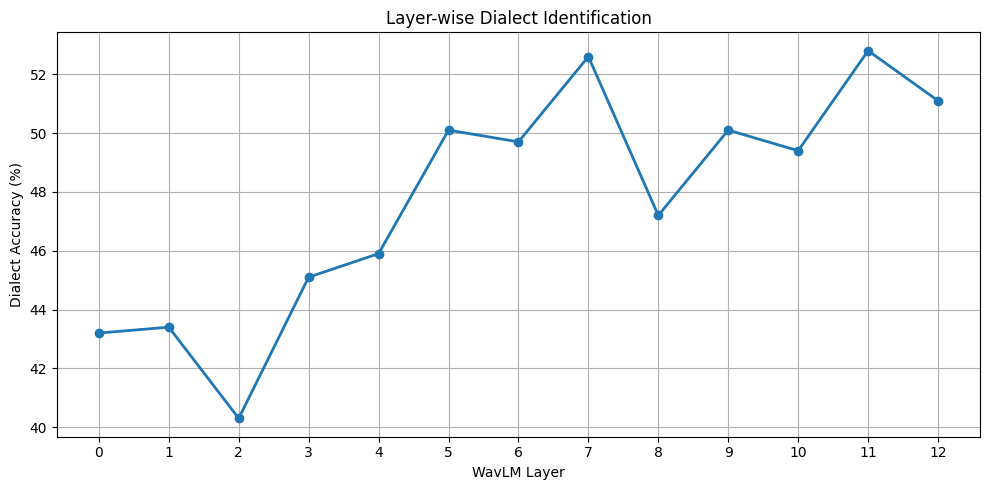

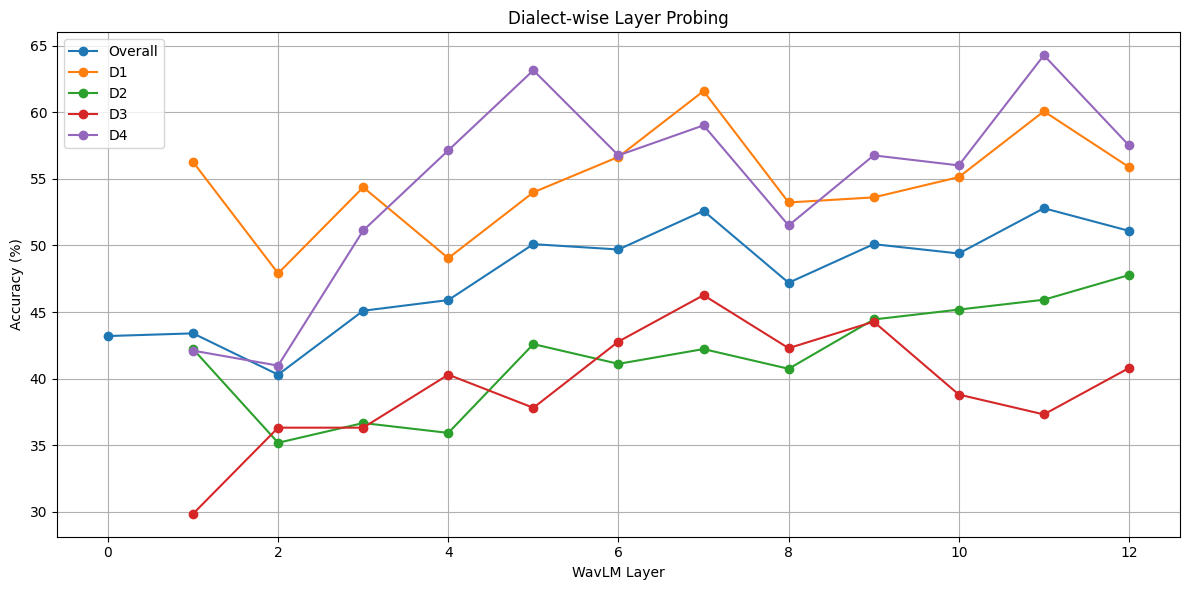


Finished Successfully.
Results saved to:
/content/drive/MyDrive/Colab Notebooks/Wavlm_features/wavlm_layerwise_dialect_results.csv
Checkpoint saved to:
/content/drive/MyDrive/Colab Notebooks/Wavlm_features/probe_checkpoint.json
Models saved to:
/content/drive/MyDrive/Colab Notebooks/Wavlm_features/saved_probes


In [ ]:
# =============================================
# INSTALL (Run once in Colab)
# =====================================================

!pip install -q tqdm scikit-learn pandas matplotlib numpy joblib

# =====================================================
# IMPORTS
# =====================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# =====================================================
# PATHS
# =====================================================

ROOT = "/content/drive/MyDrive/Colab Notebooks/Wavlm_features"

TRAIN_META = os.path.join(ROOT, "train_metadata.csv")
VAL_META = os.path.join(ROOT, "val_split.csv")

CHECKPOINT_FILE = os.path.join(
    ROOT,
    "probe_checkpoint.json"
)

RESULTS_FILE = os.path.join(
    ROOT,
    "wavlm_layerwise_dialect_results.csv"
)

MODELS_DIR = os.path.join(
    ROOT,
    "saved_probes"
)

os.makedirs(MODELS_DIR, exist_ok=True)

# =====================================================
# CHECK FILES
# =====================================================

assert os.path.exists(TRAIN_META), f"Missing: {TRAIN_META}"
assert os.path.exists(VAL_META), f"Missing: {VAL_META}"

# =====================================================
# LOAD METADATA
# =====================================================

train_df = pd.read_csv(TRAIN_META)
val_df = pd.read_csv(VAL_META)

print(f"Train Samples      : {len(train_df)}")
print(f"Validation Samples : {len(val_df)}")

# =====================================================
# LABEL ENCODING
# =====================================================

dialect_map = {
    "D1": 0,
    "D2": 1,
    "D3": 2,
    "D4": 3
}

# =====================================================
# FEATURE LOADER
# =====================================================

def load_features(df, feature_dir, desc="Loading"):

    X = []
    y = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=desc,
        leave=False
    ):

        utt_id = str(row["utt_id"])
        dialect = row["dialect"]

        if dialect not in dialect_map:
            continue

        feature_path = os.path.join(
            feature_dir,
            f"{utt_id}.npy"
        )

        if not os.path.isfile(feature_path):
            continue

        try:

            feature = np.load(feature_path)

            # If shape = (T, D)
            if feature.ndim > 1:
                feature = feature.mean(axis=0)

            feature = feature.flatten()

            X.append(feature)
            y.append(
                dialect_map[dialect]
            )

        except Exception as e:

            print(
                f"\nSkipping {feature_path}"
            )

            print(e)

    if len(X) == 0:

        return (
            np.empty((0, 0)),
            np.array([])
        )

    X = np.stack(X)
    y = np.array(y)

    return X, y

# =====================================================
# LOAD CHECKPOINT
# =====================================================

layer_acc = [None] * 13
detailed_results = []
completed_layers = set()

if os.path.exists(CHECKPOINT_FILE):

    print(
        "\nFound existing checkpoint."
    )

    with open(
        CHECKPOINT_FILE,
        "r"
    ) as f:

        checkpoint = json.load(f)

    for item in checkpoint["results"]:

        layer = item["layer"]

        # Robustly load accuracy based on available keys
        if "overall" in item: # New dialect-wise format
            overall_acc_loaded = item["overall"]
            d1_acc_loaded = item.get("D1", np.nan)
            d2_acc_loaded = item.get("D2", np.nan)
            d3_acc_loaded = item.get("D3", np.nan)
            d4_acc_loaded = item.get("D4", np.nan)
        elif "accuracy" in item: # Old original format
            overall_acc_loaded = item["accuracy"]
            d1_acc_loaded = np.nan
            d2_acc_loaded = np.nan
            d3_acc_loaded = np.nan
            d4_acc_loaded = np.nan
        elif "top1" in item: # Speaker-wise format (convert to overall for compatibility if needed)
            overall_acc_loaded = item["top1"]
            d1_acc_loaded = np.nan
            d2_acc_loaded = np.nan
            d3_acc_loaded = np.nan
            d4_acc_loaded = np.nan
        else: # Unknown format
            overall_acc_loaded = np.nan
            d1_acc_loaded = np.nan
            d2_acc_loaded = np.nan
            d3_acc_loaded = np.nan
            d4_acc_loaded = np.nan

        layer_acc[layer] = overall_acc_loaded # This list primarily tracks overall accuracy
        completed_layers.add(layer)

        detailed_results.append({
            "Layer": layer,
            "Overall": overall_acc_loaded,
            "D1": d1_acc_loaded,
            "D2": d2_acc_loaded,
            "D3": d3_acc_loaded,
            "D4": d4_acc_loaded
        })

    print(
        f"Completed Layers: "
        f"{sorted(completed_layers)}"
    )

else:

    checkpoint = {
        "results": []
    }

    print(
        "\nNo checkpoint found."
    )

# =====================================================
# LAYER-WISE PROBING
# =====================================================

for layer in tqdm(
    range(13),
    desc="Processing Layers",
    unit="layer",
    position=0
):

    # ---------------------------------
    # SKIP COMPLETED
    # ---------------------------------

    if layer in completed_layers:

        print(
            f"Layer {layer} already completed."
        )

        continue

    print("\n" + "=" * 60)
    print(f"Layer {layer}")
    print("=" * 60)

    train_dir = os.path.join(
        ROOT,
        "train",
        f"layer_{layer}"
    )

    val_dir = os.path.join(
        ROOT,
        "test",
        f"layer_{layer}"
    )

    # ---------------------------------
    # LOAD FEATURES
    # ---------------------------------

    X_train, y_train = load_features(
        train_df,
        train_dir,
        desc=f"Layer {layer} Train"
    )

    X_val, y_val = load_features(
        val_df,
        val_dir,
        desc=f"Layer {layer} Val"
    )

    print(
        "Train Shape:",
        X_train.shape
    )

    print(
        "Val Shape:",
        X_val.shape
    )

    if len(X_train) == 0:

        print(
            "No training features."
        )

        continue

    if len(X_val) == 0:

        print(
            "No validation features."
        )

        continue

    # ---------------------------------
    # NORMALIZATION
    # ---------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_val = scaler.transform(
        X_val
    )

    # ---------------------------------
    # PROBE
    # ---------------------------------

    probe = LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    )

    probe.fit(
        X_train,
        y_train
    )

    # ---------------------------------
    # EVALUATION
    # ---------------------------------

    pred = probe.predict(
        X_val
    )

    overall_acc = (
        accuracy_score(
            y_val,
            pred
        ) * 100
    )

    report = classification_report(
        y_val,
        pred,
        target_names=[
            "D1",
            "D2",
            "D3",
            "D4"
        ],
        output_dict=True,
        zero_division=0
    )

    d1_acc = (
        report["D1"]["recall"] * 100
    )

    d2_acc = (
        report["D2"]["recall"] * 100
    )

    d3_acc = (
        report["D3"]["recall"] * 100
    )

    d4_acc = (
        report["D4"]["recall"] * 100
    )

    layer_acc[layer] = overall_acc

    print("\n")
    print("=" * 70)
    print(f"LAYER {layer} RESULTS")
    print("=" * 70)

    print(
        f"Overall Accuracy : "
        f"{overall_acc:.2f}%"
    )

    print(
        f"D1 Accuracy      : "
        f"{d1_acc:.2f}%"
    )

    print(
        f"D2 Accuracy      : "
        f"{d2_acc:.2f}%"
    )

    print(
        f"D3 Accuracy      : "
        f"{d3_acc:.2f}%"
    )

    print(
        f"D4 Accuracy      : "
        f"{d4_acc:.2f}%"
    )

    print("=" * 70)

    cm = confusion_matrix(
        y_val,
        pred
    )

    print("\nConfusion Matrix")

    print(cm)

    detailed_results.append({

        "Layer": layer,

        "Overall": overall_acc,

        "D1": d1_acc,

        "D2": d2_acc,

        "D3": d3_acc,

        "D4": d4_acc

    })

    # ---------------------------------
    # SAVE MODEL
    # ---------------------------------

    model_path = os.path.join(
        MODELS_DIR,
        f"layer_{layer}_probe.pkl"
    )

    joblib.dump(
        probe,
        model_path
    )

    # ---------------------------------
    # UPDATE CHECKPOINT
    # ---------------------------------

    checkpoint["results"].append({

        "layer": int(layer),

        "overall": float(
            overall_acc
        ),

        "D1": float(
            d1_acc
        ),

        "D2": float(
            d2_acc
        ),

        "D3": float(
            d3_acc
        ),

        "D4": float(
            d4_acc
        )
    })

    with open(
        CHECKPOINT_FILE,
        "w"
    ) as f:

        json.dump(
            checkpoint,
            f,
            indent=4
        )

    # ---------------------------------
    # SAVE INTERMEDIATE CSV
    # ---------------------------------

    temp_results = pd.DataFrame({

        "Layer": list(range(13)),

        "Accuracy (%)": [
            x if x is not None else np.nan
            for x in layer_acc
        ]
    })

    temp_results.to_csv(
        RESULTS_FILE,
        index=False
    )

    pd.DataFrame(
        detailed_results
    ).to_csv(
        os.path.join(
            ROOT,
            "wavlm_dialectwise_results.csv"
        ),
        index=False
    )

    print(
        f"Checkpoint saved "
        f"after Layer {layer}"
    )

# =====================================================
# FINAL RESULTS
# =====================================================

results = pd.DataFrame({

    "Layer": list(range(13)),

    "Accuracy (%)": [
        x if x is not None else np.nan
        for x in layer_acc
    ]
})

print("\n")
print("=" * 60)
print("LAYER-WISE RESULTS")
print("=" * 60)

print(results)

print("\n")
print("=" * 70)
print("DIALECT-WISE RESULTS")
print("=" * 70)

dialect_df = pd.DataFrame(
    detailed_results
)

print(
    dialect_df.to_string(
        index=False
    )
)

results.to_csv(
    RESULTS_FILE,
    index=False
)

# =====================================================
# BEST LAYER
# =====================================================

valid_acc = [
    -1 if x is None else x
    for x in layer_acc
]

best_layer = int(
    np.argmax(valid_acc)
)

best_acc = float(
    np.max(valid_acc)
)

print("\n")
print("=" * 60)
print("BEST LAYER")
print("=" * 60)

print(
    f"Layer    : {best_layer}"
)

print(
    f"Accuracy : {best_acc:.2f}%"
)

# =====================================================
# PLOT
# =====================================================

plot_acc = [
    np.nan if x is None else x
    for x in layer_acc
]

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    range(13),
    plot_acc,
    marker="o",
    linewidth=2
)

plt.xticks(
    range(13)
)

plt.xlabel(
    "WavLM Layer"
)

plt.ylabel(
    "Dialect Accuracy (%)"
)

plt.title(
    "Layer-wise Dialect Identification"
)

plt.grid(True)

plt.tight_layout()

plt.show()

dialect_df = pd.DataFrame(
    detailed_results
)

plt.figure(
    figsize=(12,6)
)

plt.plot(
    dialect_df["Layer"],
    dialect_df["Overall"],
    marker="o",
    label="Overall"
)

plt.plot(
    dialect_df["Layer"],
    dialect_df["D1"],
    marker="o",
    label="D1"
)

plt.plot(
    dialect_df["Layer"],
    dialect_df["D2"],
    marker="o",
    label="D2"
)

plt.plot(
    dialect_df["Layer"],
    dialect_df["D3"],
    marker="o",
    label="D3"
)

plt.plot(
    dialect_df["Layer"],
    dialect_df["D4"],
    marker="o",
    label="D4"
)

plt.xlabel(
    "WavLM Layer"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Dialect-wise Layer Probing"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nFinished Successfully.")
print(
    f"Results saved to:\n{RESULTS_FILE}"
)

print(
    f"Checkpoint saved to:\n{CHECKPOINT_FILE}"
)

print(
    f"Models saved to:\n{MODELS_DIR}"
)

In [ ]:
!nvidia-smi


Mon Jun 22 05:10:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----